# E6：vae 后验初始化 + BaM 100 步 refinement（cifar10 全 test set）

协议同论文 §7.5：从收敛 VAE 的后验 (mu, diag(exp(logvar))) 初始化，BaM refinement T=100、B=300、λ=7500、σ²=1.0、v2。
逐图记录 MSE/mu 轨迹存 npz 分片；统计段做配对检验 + box 图。

In [1]:
import warnings
import traceback
import sys

# 设置警告处理，将RuntimeWarning转换为异常或详细打印
def warning_handler(message, category, filename, lineno, file=None, line=None):
    # print(f"  警告捕获:")
    print(f"  警告: {category.__name__}")
    print(f"  消息: {message}")
    # print(f"  文件: {filename}")
    # print(f"  行号: {lineno}")
    if line:
        print(f"  代码行: {line}")
    # print(f"  调用栈:")
    # for frame_info in traceback.extract_stack()[:-1]:  # 排除当前frame
    #     print(f"    {frame_info.filename}:{frame_info.lineno} in {frame_info.name}")
    #     if frame_info.line:
    #         print(f"      {frame_info.line}")
    # print("="*50)

# 注册警告处理器
warnings.showwarning = warning_handler

print("警告处理器已设置")

警告处理器已设置


In [2]:
import multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.image.fid import FrechetInceptionDistance
import numpy as np
import random
import matplotlib.pyplot as plt
import optax

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import datasets
from datasets import load_from_disk, Image
from torch.utils.tensorboard import SummaryWriter
import math
import copy
from datetime import datetime


mp.set_start_method("spawn", force=True)
time_stamp = datetime.now().strftime('%m-%d_%H-%M')

In [3]:
import os
import random
import numpy as np
import torch
import jax


def set_seed(seed: int):
    # 1. Python random
    random.seed(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 如果你用多个 GPU

    # 4. cuDNN 设置为确定性模式，关闭 benchmark
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True





def seed_worker(worker_id):
    # 每个 worker 基于相同或偏移后的种子
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


# 在脚本最上方调用一次
SEED = 42
set_seed(SEED)

# PyTorch 1.7+ 可直接用 generator
gen = torch.Generator()
gen.manual_seed(SEED)

MASTER_JAX_KEY = jax.random.PRNGKey(SEED)

## config

In [ ]:
# ===== E6 refinement 配置（唯一需要按方法/分片改动的 cell）=====
METHOD_TAG = "vae"   # sdvae / vae
DATASET = "cifar10"
CKPT = "/home/yzm/ipy/runs__tsne/G1-latent20-cif10-vae-lr0.0005-143-12-11_20-30/final_model.pt"

SHARD_ID = 0        # 本分片编号 0..NUM_SHARDS-1；并行时复制本 notebook 或转 .py，各改此值
NUM_SHARDS = 1      # 总分片数

T = 100             # refinement 迭代步数（论文 §7.5 协议）
B = 2             # BaM 每步采样数
LAMBDA_T = 10
SIGMA2 = 1.0
BAM_VERSION = "v2"
JITTER = 1e-6
SEED = 42

cuda_num = 2
SAVE_DIR = "/home/yzm/ipy/e6_iter_results_B2"
import os
os.makedirs(SAVE_DIR, exist_ok=True)


## vae class

In [ ]:
class VAE_Encoder(nn.Module):
    """
    VAE的encoder，将输入的图片映射到隐变量的分布，输出隐变量分布的均值和方差.
    由于方差不能为负，所以这里输出的是log(方差)，而不是方差本身.
    """

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE_Encoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh()
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)


class VAE_Decoder(nn.Module):
    """
    VAE的decoder，将隐变量映射回图片.
    """

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE_Decoder, self).__init__()

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.decoder(z)


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=500, latent_dim=5):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        self.encoder = VAE_Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = VAE_Decoder(input_dim, hidden_dim, latent_dim)

    def encode(self, x):
        """
        将输入的图片映射到隐变量的分布，输出隐变量分布的均值和log(方差).
        """
        return self.encoder(x)

    def decode(self, z):
        """
        将隐变量映射回图片.
        """
        return self.decoder(z)

    def reparameterize(self, mu, logvar):
        """
        重参数化技巧，先从标准正态分布中采样一个epsilon，然后根据隐变量分布的均值和方差，计算出隐变量.
        """
        std = torch.exp(0.5 * logvar)  # 计算标准差, std = sqrt(var) = sqrt(exp(logvar)) = exp(logvar/2)
        epsilon = torch.randn_like(std, requires_grad=False)  # 从标准正态分布中采样epsilon
        return mu + epsilon * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

## data (test only)

In [6]:
# 只加载 test（E6 只用 test set）
data_folder = "data_cifar10"
s = 32
p = 3
INPUT_DIM = p * s * s
LATENT_DIM = 20
HIDDEN_DIM = LATENT_DIM * 100

test_dataset = datasets.load_from_disk(f"/home/yzm/{data_folder}/test")
test_images = (
    torch.stack([torch.tensor(np.array(img)) for img in test_dataset["img"]]).float()
    / 255.0
)
test_images = test_images.permute(0, 3, 1, 2)   # [N,32,32,3] -> [N,3,32,32]
test_images = test_images.flatten(start_dim=1)  # [N, 3072]
print("test:", test_images.shape)


test: torch.Size([10000, 3072])


## BaM

In [ ]:
import jax
import jax.numpy as jnp
from jax import jit, random
from jax.scipy.linalg import sqrtm as sqrtm_jsp
from scipy.linalg import sqrtm as sqrtm_sp
import numpy as np
import scipy.sparse as spys
from jax.lib import xla_bridge
import jax.debug

class BaM_V0:
    """
    Wrapper class for using BaM updates to fit a distribution
    """
    def __init__(self, D, lp, lp_g, use_lowrank=False, jit_compile=True):
        """
        Inputs:
          D: (int) Dimensionality (number) of parameters
          lp : Function to evaluate target log-probability distribution.
               (Only used in monitor, not for fitting)
          lp_g : Function to evaluate score, i.e. the gradient of the target log-probability distribution
        """
        #print("Using BaM V0")
        self.D = D
        self.lp = lp
        self.lp_g = lp_g
        self.use_lowrank = use_lowrank
        if use_lowrank:
            print("Using lowrank update")
        self.jit_compile = jit_compile
        if not jit_compile:
            print("Not using jit compilation. This may take longer than it needs to.")

    def compute_Q_host(U_B):
        U, B = U_B
        UU, DD, VV = spys.linalg.svds(U, k=B)
        return UU * np.sqrt(DD)

    def compute_Q(self, U_B):
        result_shape = jax.ShapeDtypeStruct((U_B[0].shape[0], U_B[1]), U_B[0].dtype)
        return jax.pure_callback(self.compute_Q_host, result_shape, U_B)

    def get_sqrt(self, M):
        if xla_bridge.get_backend().platform == 'gpu':
            result_shape = jax.ShapeDtypeStruct(M.shape, M.dtype)
            M_root = jax.pure_callback(lambda x:sqrtm_sp(x).astype(M.dtype), result_shape, M) # sqrt can be complex sometimes, we only want real part
        elif xla_bridge.get_backend().platform == 'cpu':
            M_root = sqrtm_jsp(M)
        else:
            print("Backend not recongnized in get_sqrt function. Should be either gpu or cpu")
            raise
        return M_root.real


    def bam_update(self, samples, vs, mu0, S0, reg):
        """
        Returns updated mean and covariance matrix with batch and match updates.
        For a batch, this is simply the mean of updates for individual samples.

        Inputs:
        samples: Array of samples of shape BxD where B is the batch dimension
        vs : Array of score functions of shape BxD corresponding to samples
        mu0 : Array of shape D, current estimate of the mean
        S0 : Array of shape DxD, current estimate of the covariance matrix

        Returns:
        mu : Array of shape D, new estimate of the mean
        S : Array of shape DxD, new estimate of the covariance matrix
        """

        assert len(samples.shape) == 2
        assert len(vs.shape) == 2
        B = samples.shape[0]
        xbar = jnp.mean(samples, axis=0)
        # jax.debug.print("Shape of samples: {samples_shape}", samples_shape=samples.shape)
        # jax.debug.print("Shape of xbar: {xbar_shape}", xbar_shape=xbar.shape)

        outer_map = jax.vmap(jnp.outer, in_axes=(0, 0))
        xdiff = samples - xbar
        C = jnp.mean(outer_map(xdiff, xdiff), axis=0)

        gbar = jnp.mean(vs, axis=0)
        gdiff = vs - gbar
        G = jnp.mean(outer_map(gdiff, gdiff), axis=0)

        U = reg * G + (reg)/(1+reg) * jnp.outer(gbar, gbar)
        V = S0 + reg * C + (reg)/(1+reg) * jnp.outer(mu0 - xbar, mu0 - xbar)
        I = jnp.identity(samples.shape[1])

        mat = I + 4 * jnp.matmul(U, V)
        # S = 2 * jnp.matmul(V, jnp.linalg.inv(I + sqrtm(mat).real))
        S = 2 * jnp.linalg.solve(I + self.get_sqrt(mat).T, V.T)

        mu = 1/(1+reg) * mu0 + reg/(1+reg) * (jnp.matmul(S, gbar) + xbar)

        return mu, S


    def bam_lowrank_update(self, samples, vs, mu0, S0, reg):
        """
        Returns updated mean and covariance matrix with low-rank BaM updates.
        For a batch, this is simply the mean of updates for individual samples.

        Inputs:
        samples: Array of samples of shape BxD where B is the batch dimension
        vs : Array of score functions of shape BxD corresponding to samples
        mu0 : Array of shape D, current estimate of the mean
        S0 : Array of shape DxD, current estimate of the covariance matrix

        Returns:
        mu : Array of shape D, new estimate of the mean
        S : Array of shape DxD, new estimate of the covariance matrix
        """

        assert len(samples.shape) == 2
        assert len(vs.shape) == 2
        B = samples.shape[0]
        xbar = jnp.mean(samples, axis=0)
        outer_map = jax.vmap(jnp.outer, in_axes=(0, 0))
        xdiff = samples - xbar
        C = jnp.mean(outer_map(xdiff, xdiff), axis=0)

        gbar = jnp.mean(vs, axis=0)
        gdiff = vs - gbar
        G = jnp.mean(outer_map(gdiff, gdiff), axis=0)

        U = reg * G + (reg)/(1+reg) * jnp.outer(gbar, gbar)
        V = S0 + reg * C + (reg)/(1+reg) * jnp.outer(mu0 - xbar, mu0 - xbar)

        # Form decomposition that is D x K
        Q = self.compute_Q((U, B))
        I = jnp.identity(B)
        VT = V.T
        A = VT.dot(Q)
        BB = 0.5*I + jnp.real(self.get_sqrt(A.T.dot(Q) + 0.25*I))
        BB = BB.dot(BB)
        CC = jnp.linalg.solve(BB, A.T)
        S = VT - A @ CC
        mu = 1/(1+reg) * mu0 + reg/(1+reg) * (jnp.matmul(S, gbar) + xbar)

        return mu, S



    def fit(self, key, regf, mean=None, cov=None, batch_size=2, niter=5000, nprint=10, verbose=True, check_goodness=True, monitor=None, retries=10, jitter=1e-6, debug_covariance=False):
        """
        Main function to fit a multivariate Gaussian distribution to the target

        Inputs:
          key: Random number generator key (jax.random.PRNGKey)
          mean : Function to return regularizer value at an iteration. See Regularizers class below
          mean : Optional, initial value of the mean. Expected None or array of size D
          cov : Optional, initial value of the covariance matrix. Expected None or array of size DxD
          batch_size : Optional, int. Number of samples to match scores for at every iteration
          niter : Optional, int. Total number of iterations
          nprint : Optional, int. Number of iterations after which to print logs
          verbose : Optional, bool. If true, print number of iterations after nprint
          check_goodness : Optional, bool. Recommended. Wether to check floating point errors in covariance matrix update
          monitor : Optional. Function to monitor the progress and track different statistics for diagnostics.
                    Function call should take the input tuple (iteration number, [mean, cov], lp, key, number of grad evals).
                    Example of monitor class is provided in utils/monitors.py

        Returns:
          mu : Array of shape D, fit of the mean
          cov : Array of shape DxD, fit of the covariance matrix
        """
        # if jitter != 0:
        #     print("Using jitter:", jitter)
        # else:
        #     print("Not using jitter")

        if mean is None:
            mean = jnp.zeros(self.D)
        if cov is None:
            cov = jnp.identity(self.D)

        nevals = 1

        if self.use_lowrank:
            update_function = self.bam_lowrank_update
        else:
            update_function = self.bam_update
        if self.jit_compile:
            update_function = jit(update_function)

        if nprint > niter: nprint = niter
        for i in range(niter + 1):
            if (i%(niter//nprint) == 0) and verbose :
                print(f'Iteration {i} of {niter}')

            if monitor is not None:
                if (i%monitor.checkpoint) == 0:
                    monitor(i, [mean, cov], self.lp, key, nevals=nevals)
                    nevals = 0

            # Can generate samples from jax distribution (commented below), but using numpy is faster
            j = 0
            while True:         # Sometimes run crashes due to a bad sample. Avoid that by re-trying.
                try:
                    key, key_sample = random.split(key, 2)
                    np.random.seed(key_sample[0])
                    # Generate samples using NumPy outside the jit-compiled function
                    samples = np.random.multivariate_normal(mean=np.array(mean), cov=np.array(cov), size=batch_size)
                    vs = self.lp_g(samples)
                    nevals += batch_size
                    reg = regf(i)
                    # Pass NumPy arrays to the jit-compiled function
                    mean_new, cov_new = update_function(jnp.array(samples), jnp.array(vs), mean, cov, reg)
                    cov_new += np.eye(self.D) * jitter # jitter covariance matrix
                    cov_new = (cov_new + cov_new.T)/2.
                    
                    break
                except Exception as e:
                    if j < retries :
                        j += 1
                        print(f"Failed with exception {e}")
                        print(f"Trying again {j} of {retries}")
                    else : raise e

            is_good = self._check_goodness(cov_new)
            if is_good:
                mean, cov = mean_new, cov_new
            else:
                if verbose: print("Bad update for covariance matrix. Revert")

        if monitor is not None:
            monitor(i, [mean, cov], self.lp, key, nevals=nevals)
        return mean, cov


    def _check_goodness(self, cov):
        '''
        Internal function to check if the new covariance matrix is a valid covariance matrix.
        Required due to floating point errors in updating the convariance matrix directly,
        insteead of it's Cholesky form.
        '''
        is_good = False
        try:
            if (np.isnan(np.linalg.cholesky(cov))).any():
                pass
            else:
                is_good = True
            return is_good
        except:
            return is_good



In [ ]:
class Regularizers:
    """
    Class for regularizers used in BaM
    """

    def __init__(self):
        self.counter = 0  # 被调用次数

    def reset(self):
        self.counter = 0

    def constant(self, reg0):
        def reg_iter(iteration):
            self.counter += 1
            return reg0  # 返回常数正则化值

        return reg_iter

    def linear(self, reg0):
        def reg_iter(iteration):
            self.counter += 1
            return reg0 / self.counter  # 返回线性递减正则化值

        return reg_iter

    def custom(self, func):
        def reg_iter(iteration):
            self.counter += 1
            return func(self.counter)  # 返回自定义正则化函数

        return reg_iter

In [ ]:
import jax
import jax.numpy as jnp
from jax import jit, random
from jax.scipy.linalg import sqrtm as sqrtm_jsp
from scipy.linalg import sqrtm as sqrtm_sp
import numpy as np

# import scipy.sparse as spys
from scipy.sparse.linalg import svds
from jax.lib import xla_bridge



class BaM_V2:
    """
    Wrapper class for using BaM updates to fit a distribution
    """

    def __init__(self, D, lp, lp_g, use_lowrank=False, jit_compile=True):
        """
        Inputs:
          D: (int) Dimensionality (number) of parameters
          lp : Function to evaluate target log-probability distribution.
                         (Only used in monitor, not for fitting)
          lp_g : Function to evaluate score, i.e. the gradient of the target log-probability distribution

          是否使用低秩近似（减少计算成本和内存使用）和 JIT 编译（加速计算）
        """
        #print("Using Bam v2")
        self.D = D
        self.lp = lp
        self.lp_g = lp_g
        self.use_lowrank = use_lowrank
        if use_lowrank:
            print("Using lowrank update")
        self.jit_compile = jit_compile
        if not jit_compile:
            print("Not using jit compilation. This may take longer than it needs to.")

    # 用于低秩更新
    def compute_Q_host(U_B):
        U, B = U_B
        # UU, DD, VV = spys.linalg.svds(U, k=B)
        U = np.array(U)
        UU, DD, VV = svds(U, k=B)  # 奇异值分解→三个矩阵
        # B：要计算的奇异值的个数，设为batchsize
        return UU * np.sqrt(DD)


    def compute_Q(self, U_B):
        result_shape = jax.ShapeDtypeStruct((U_B[0].shape[0], U_B[1]), U_B[0].dtype)
        return jax.pure_callback(self.compute_Q_host, result_shape, U_B)
        # 将 compute_Q_host 函数包装为一个可以在 JAX 计算图中使用的纯函数


    # 计算矩阵 M 的平方根
    def get_sqrt(self, M):
        if xla_bridge.get_backend().platform == "gpu":
            result_shape = jax.ShapeDtypeStruct(M.shape, M.dtype)
            M_root = jax.pure_callback(
                lambda x: sqrtm_sp(x).astype(M.dtype), result_shape, M
            )
            # sqrt can be complex sometimes, we only want real part
        elif xla_bridge.get_backend().platform == "cpu":
            M_root = sqrtm_jsp(M)
        else:
            print(
                "Backend not recongnized in get_sqrt function. Should be either gpu or cpu"
            )
            raise
        return M_root.real


    def check_spd(self, M, name, eps=1e-8):
        """
        用 jax.debug.print 打印 M 的对称误差、最小/最大特征值，
        以及一个 SPD? 标志（min_eig >= -eps）。
        这个函数里不做 Python 层面的 if-branch，JAX 下不会报 TracerBoolConversionError。
        """
        # 1) 对称误差
        sym_err = jnp.linalg.norm(M - M.T)

        # 2) 强制取真正对称矩阵去算特征值
        M_sym = (M + M.T) * 0.5
        w = jnp.linalg.eigvalsh(M_sym)

        # 3) SPD 判定（仍是 JAX 布尔标量）
        is_spd = w[0] >= -eps

        # 4) 打印
        jax.debug.print(
            "[SPD] {}  sym_err={:.2e}  eig_min={:.2e}  eig_max={:.2e}  SPD?={}",
            name,
            sym_err,
            w[0],
            w[-1],
            is_spd,
        )

        return M  # 返回原矩阵，不改计算图


    # 更新均值和协方差矩阵
    def bam_update(self, samples, vs, mu0, S0, reg):
        """
        Returns updated mean and covariance matrix with batch and match updates.
        For a batch, this is simply the mean of updates for individual samples.

        Inputs:
        samples: Array of samples of shape BxD where B is the batch dimension
        vs : Array of score functions of shape BxD corresponding to samples
        mu0 : Array of shape D, current estimate of the mean
        S0 : Array of shape DxD, current estimate of the covariance matrix
        reg : Regularization parameter (lambda_t)

        Returns:
        mu : Array of shape D, new estimate of the mean
        S : Array of shape DxD, new estimate of the covariance matrix
        """
        # (B, D)
        assert len(samples.shape) == 2
        assert len(vs.shape) == 2
        B = samples.shape[0]
        outer_map = jax.vmap(jnp.outer, in_axes=(0, 0))
        # 使用 jax.vmap 对 jnp.outer 进行向量化 → 可以对多个向量进行外积运算

        gbar = jnp.mean(vs, axis=0)
        zbar = jnp.mean(samples, axis=0)

        A = samples - (1 / (1 + reg)) * mu0 - (reg / (1 + reg)) * zbar
        U = reg * (
            jnp.mean(outer_map(vs, vs), axis=0) - (reg / (1 + reg)) * jnp.outer(gbar, gbar)
        )
        V = (
            reg * jnp.mean(outer_map(A, A), axis=0)
            + S0
            + (reg**2 / (1 + reg) ** 2) * jnp.outer(mu0 - zbar, mu0 - zbar)
        )

        I = jnp.identity(samples.shape[1])
        mat = I + 4 * jnp.matmul(U, V)
        S = 2 * jnp.matmul(V, jnp.linalg.inv(I + self.get_sqrt(mat)))

        mu = (
            (1 / (1 + reg)) * mu0
            + (reg / (1 + reg)) * zbar
            + (reg / (1 + reg)) * jnp.matmul(S, gbar)
        )

        return mu, S


    # 更新均值和协方差矩阵
    def bam_update_debug(self, samples, vs, mu0, S0, reg):
        """
        Returns updated mean and covariance matrix with batch and match updates.
        For a batch, this is simply the mean of updates for individual samples.

        Inputs:
        samples: Array of samples of shape BxD where B is the batch dimension
        vs : Array of score functions of shape BxD corresponding to samples
        mu0 : Array of shape D, current estimate of the mean
        S0 : Array of shape DxD, current estimate of the covariance matrix
        reg : Regularization parameter (lambda_t)

        Returns:
        mu : Array of shape D, new estimate of the mean
        S : Array of shape DxD, new estimate of the covariance matrix
        """
        # (B, D)
        assert len(samples.shape) == 2
        assert len(vs.shape) == 2

        B = samples.shape[0]
        outer_map = jax.vmap(jnp.outer, in_axes=(0, 0))
        # 使用 jax.vmap 对 jnp.outer 进行向量化 → 可以对多个向量进行外积运算

        gbar = jnp.mean(vs, axis=0)
        zbar = jnp.mean(samples, axis=0)

        A = samples - (1 / (1 + reg)) * mu0 - (reg / (1 + reg)) * zbar
        U = reg * (
            jnp.mean(outer_map(vs, vs), axis=0) - (reg / (1 + reg)) * jnp.outer(gbar, gbar)
        )
        V = (
            reg * jnp.mean(outer_map(A, A), axis=0)
            + S0
            + (reg**2 / (1 + reg) ** 2) * jnp.outer(mu0 - zbar, mu0 - zbar)
        )

        I = jnp.identity(samples.shape[1])
        mat = I + 4 * jnp.matmul(U, V)
        S = 2 * jnp.matmul(V, jnp.linalg.inv(I + get_sqrt(mat)))

        mu = (
            (1 / (1 + reg)) * mu0
            + (reg / (1 + reg)) * zbar
            + (reg / (1 + reg)) * jnp.matmul(S, gbar)
        )

        jax.debug.print("score: {}", vs)
        # ---- SPD 检查点 1: U, V, S0(旧) ----
        self.check_spd(U, "U (score-cov term)")
        self.check_spd(V, "V (batch-stats term)")
        self.check_spd(S0, "Sigma_old")

        # ---- SPD 检查点 2: S_cand(新) ----
        self.check_spd(S, "Sigma_new")

        return mu, S


    # 低秩BaM更新均值和协方差矩阵
    def bam_lowrank_update(self, samples, vs, mu0, S0, reg):
        """
        Returns updated mean and covariance matrix with low-rank BaM updates.
        For a batch, this is simply the mean of updates for individual samples.

        Inputs:
        samples: Array of samples of shape BxD where B is the batch dimension
        vs : Array of score functions of shape BxD corresponding to samples
        mu0 : Array of shape D, current estimate of the mean
        S0 : Array of shape DxD, current estimate of the covariance matrix

        Returns:
        mu : Array of shape D, new estimate of the mean
        S : Array of shape DxD, new estimate of the covariance matrix
        """

        assert len(samples.shape) == 2
        assert len(vs.shape) == 2

        B = samples.shape[0]
        xbar = jnp.mean(samples, axis=0)
        outer_map = jax.vmap(jnp.outer, in_axes=(0, 0))
        xdiff = samples - xbar
        C = jnp.mean(outer_map(xdiff, xdiff), axis=0)

        gbar = jnp.mean(vs, axis=0)
        gdiff = vs - gbar
        G = jnp.mean(outer_map(gdiff, gdiff), axis=0)

        U = reg * G + (reg) / (1 + reg) * jnp.outer(gbar, gbar)
        V = S0 + reg * C + (reg) / (1 + reg) * jnp.outer(mu0 - xbar, mu0 - xbar)

        # Form decomposition that is D x K
        # 低秩分解
        Q = self.compute_Q((U, B))  # 低秩矩阵Q，用于近似矩阵U
        I = jnp.identity(B)  # 大小为B的单位矩阵
        VT = V.T  # 转置
        A = VT.dot(Q)
        BB = 0.5 * I + jnp.real(self.get_sqrt(A.T.dot(Q) + 0.25 * I))
        BB = BB.dot(BB)
        CC = jnp.linalg.solve(BB, A.T)
        S = VT - A @ CC
        mu = 1 / (1 + reg) * mu0 + reg / (1 + reg) * (jnp.matmul(S, gbar) + xbar)

        return mu, S


    # 协方差矩阵检查函数
    def check_covariance_matrix(cov, iteration, debug=True):
        """检查协方差矩阵的性质并打印调试信息"""
        issues = []
        
        # 检查对称性
        if not np.allclose(cov, cov.T, atol=1e-10):
            issues.append("not symmetric")
        
        # 检查特征值（正定性）
        try:
            eigenvals = np.linalg.eigvals(cov)
            min_eigenval = np.min(eigenvals)
            if min_eigenval <= 0:
                issues.append(f"not positive definite (min eigenvalue: {min_eigenval:.2e})")
        except Exception as e:
            issues.append(f"eigenvalue computation failed: {e}")
        
        # 检查是否包含NaN或Inf
        if np.any(np.isnan(cov)):
            issues.append("contains NaN")
        if np.any(np.isinf(cov)):
            issues.append("contains Inf")
        
        # 条件数检查
        try:
            cond_num = np.linalg.cond(cov)
            if cond_num > 1e12:
                issues.append(f"ill-conditioned (condition number: {cond_num:.2e})")
        except Exception as e:
            issues.append(f"condition number computation failed: {e}")
        
        if debug and issues:
            print(f"[Iteration {iteration}] Covariance matrix issues: {', '.join(issues)}")
            print(f"  Matrix shape: {cov.shape}")
            print(f"  Matrix norm: {np.linalg.norm(cov):.2e}")
            try:
                print(f"  Diagonal elements range: [{np.min(np.diag(cov)):.2e}, {np.max(np.diag(cov)):.2e}]")
            except:
                pass
        
        return len(issues) == 0, issues

    def fit(
        self,
        key,
        regf,
        mean=None,
        cov=None,
        batch_size=2,
        niter=5000,
        nprint=10,
        verbose=True,
        check_goodness=True,
        monitor=None,
        retries=10,
        jitter=1e-6,
        debug_covariance=False,  # 新增调试参数
    ):
        """
        Main function to fit a multivariate Gaussian distribution to the target

        Inputs:
          key: Random number generator key (jax.random.PRNGKey)
          regf : Function to return regularizer value at an iteration. See Regularizers class below
          正则化函数
          mean : Optional, initial value of the mean. Expected None or array of size D
          cov : Optional, initial value of the covariance matrix. Expected None or array of size DxD
          batch_size : Optional, int. Number of samples to match scores for at every iteration
          niter : Optional, int. Total number of iterations
          最大迭代次数
          nprint : Optional, int. Number of iterations after which to print logs
          verbose : Optional, bool. If true, print number of iterations after nprint
          debug_covariance : bool. If true, check and print covariance matrix issues
          monitor : Optional. Function to monitor the progress and track different statistics for diagnostics.
                    Function call should take the input tuple (iteration number, [mean, cov], lp, key, number of grad evals).
                    Example of monitor class is provided in utils/monitors.py

        Returns:
          mu : Array of shape D, fit of the mean
          cov : Array of shape DxD, fit of the covariance matrix
        """

        # if jitter != 0:
        #     print("Using jitter:", jitter)
        # else:
        #     print("Not using jitter")
            
        # 初始化
        if mean is None:
            mean = jnp.zeros(self.D)
        if cov is None:
            cov = jnp.identity(self.D)  # DxD

        nevals = 1  # 梯度评估次数

        if self.use_lowrank:
            update_function = self.bam_lowrank_update
        else:
            update_function = self.bam_update
        if self.jit_compile:
            update_function = jit(update_function)

        if nprint > niter:
            nprint = niter

        for i in range(niter + 1):
            if (i % (niter // nprint) == 0) and verbose:
                print(f"Iteration {i} of {niter}")

            # 调用监控函数 monitor，并将梯度评估次数 nevals 重置为 0
            if monitor is not None:
                if (i % monitor.checkpoint) == 0:
                    monitor(i, [mean, cov], self.lp, key, nevals=nevals)
                    nevals = 0

            # Can generate samples from jax distribution (commented below), but using numpy is faster
            j = 0
            while (
                True
            ):  # Sometimes run crashes due to a bad sample. Avoid that by re-trying.
                try:
                    key, key_sample = random.split(key, 2)
                    np.random.seed(key_sample[0])

                    # 从当前高斯分布中抽取 batch_size 个样本

                    try:
                        samples = np.random.multivariate_normal(
                            mean=mean, cov=cov, size=batch_size
                        )

                        if debug_covariance:
                            print(f"[Iteration {i}] 生成 {batch_size} 个样本...")
                            print(f"当前 q 的均值: {mean}, \n 协方差矩阵:{cov}")
                            print(f"[Iteration {i}] 样本生成成功")
                            print("样本均值:", samples.mean(axis=0))  # 每个维度的平均值
                            print("样本协方差:", np.cov(samples.T))  # 各维度之间的协方差

                    except Exception as sample_error:
                        print(f"[Iteration {i}] ❌ 样本生成失败: {sample_error}")
                        print(f"  协方差矩阵统计:")
                        print(f"    形状: {np.array(cov).shape}")
                        print(f"    范围: [{np.min(cov):.2e}, {np.max(cov):.2e}]")
                        print(f"    对角线元素: {np.diag(cov)}")
                        raise sample_error

                    # 计算样本的得分
                    vs = self.lp_g(samples)
                    nevals += batch_size
                    # 正则化
                    reg = regf(i)

                    # 更新参数
                    if debug_covariance:
                        mean_new, cov_new = self.bam_update_debug(samples, vs, mean, cov, reg)
                    else:
                        mean_new, cov_new = self.bam_update(samples, vs, mean, cov, reg)

                    # 检查更新后的协方差矩阵
                    if debug_covariance:
                        print(f"[Iteration {i}] 的lambda (reg={reg:.2e})...")
                        is_valid_new, issues_new = self.check_covariance_matrix(np.array(cov_new), i, debug=False)
                        if not is_valid_new:
                            print(f"[Iteration {i}] ⚠️  更新后的协方差矩阵有问题: {', '.join(issues_new)}")
                            print(cov_new)
                            print(f"mu_{i} = {mean_new}")

                    cov_new += np.eye(self.D) * jitter # jitter covariance matrix
                    cov_new = (cov_new + cov_new.T)/2.

                    mean, cov = mean_new, cov_new

                    break

                except Exception as e:
                    if j < retries:
                        j += 1
                        print(f"[Iteration {i}] Failed with exception {e}")
                        print(f"  Trying again {j} of {retries}")
                    else:
                        print(f"[Iteration {i}] 达到最大重试次数，抛出异常")
                        raise e

        if monitor is not None:
            monitor(i, [mean, cov], self.lp, key, nevals=nevals)

        return mean, cov


## score fn

In [ ]:
def make_lp_and_score_fn(x_target_np, decoder, sigma2=0.1):
    """
    返回两个函数：
    1. lp_fn: 计算 log p(z,x_target)
    2. score_fn: 计算 ∇_z log p(z,x_target)
    通过复用 log probability 计算来避免重复代码
    """
    # 固定目标图像
    x_t = torch.from_numpy(x_target_np).float().to(device).unsqueeze(0)

    def compute_logp(z_tensor):
        """计算 log p(z,x_target)，返回 torch tensor"""
        # log p(z) = -½||z||²
        lpz = -0.5 * (z_tensor**2).sum(dim=1)

        # log p(x|z) = -½/σ² ||x_t - decoder(z)||²
        xrec = decoder(z_tensor)
        err = x_t - xrec
        lpx = -0.5 / sigma2 * err.view(z_tensor.size(0), -1).pow(2).sum(dim=1)

        return lpz + lpx

    def lp_fn(samples_np):
        """计算 log p(z,x_target)，返回 numpy array"""
        z = torch.from_numpy(samples_np).float().to(device)
        with torch.no_grad():  # 不需要梯度
            logp = compute_logp(z)
        return logp.detach().cpu().numpy()

    def score_fn(samples_np):
        """计算 ∇_z log p(z,x_target)，返回 numpy array"""
        z = torch.from_numpy(samples_np).float().to(device)
        z.requires_grad_(True)

        # 复用 compute_logp 函数
        logp = compute_logp(z).sum()  # 求和后再求梯度
        (grad_z,) = torch.autograd.grad(logp, z)

        return grad_z.detach().cpu().numpy()

    return lp_fn, score_fn

In [ ]:
def make_bam(version="v2", **kwargs):
    if version == "v0":
        return BaM_V0(**kwargs)
    elif version == "v2":
        return BaM_V2(**kwargs)
    else:
        raise ValueError("version must be 'v0' or 'v2'")

## refinement runner

In [12]:
device = torch.device(f"cuda:{cuda_num}" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = torch.load(CKPT, weights_only=False, map_location=device)
model.to(device)
model.eval()
ENCODER = model.encoder.to(device)
decoder = model.decoder.to(device)
print("loaded:", CKPT)


device: cuda:2
loaded: /home/yzm/ipy/runs__tsne/G1-latent20-cif10-vae-lr0.0005-143-12-11_20-30/final_model.pt


In [ ]:
class TrajMonitor:
    """记录每步 mean 解码 MSE 与 mean 轨迹。mse[0] = encoder 后验均值的初始重构 MSE（未 refinement）。"""

    def __init__(self, decoder, x_target, checkpoint=1):
        self.mse = []
        self.mus = []
        self.decoder = decoder.eval()
        self.x_target = x_target.detach().cpu()
        self.checkpoint = checkpoint
        self.offset_evals = 0

    def __call__(self, i, params, lp, key, nevals=1):
        mu, cov = params
        mu_np = np.asarray(mu, dtype=np.float64)
        with torch.no_grad():
            z = (
                torch.from_numpy(mu_np)
                .float()
                .unsqueeze(0)
                .to(next(self.decoder.parameters()).device)
            )
            x_rec = self.decoder(z).detach().cpu().view_as(self.x_target)
        self.mse.append(torch.sum((x_rec - self.x_target) ** 2).item())
        self.mus.append(mu_np.copy())
        return key


def run_refine_for_image(x_tensor, encoder, decoder):
    """从 encoder 后验 (mu, diag(exp(logvar))) 初始化，跑 T 步 BaM refinement，返回轨迹 monitor。"""
    encoder.eval()
    with torch.no_grad():
        mu_e, logvar_e = encoder(x_tensor)
        mean_init = mu_e.squeeze().cpu().numpy().astype(np.float64)
        cov_init = np.diag(np.exp(logvar_e.squeeze().cpu().numpy().astype(np.float64)))

    x_numpy = x_tensor.detach().cpu().numpy()
    lp_fn, score_fn = make_lp_and_score_fn(x_numpy, decoder, sigma2=SIGMA2)

    solver = make_bam(
        version=BAM_VERSION, D=LATENT_DIM, lp=lp_fn, lp_g=score_fn,
        use_lowrank=False, jit_compile=True,
    )
    reg = Regularizers().constant(LAMBDA_T)
    monitor = TrajMonitor(decoder, x_tensor, checkpoint=1)

    key = jax.random.PRNGKey(SEED)
    np.random.seed(SEED)
    mu, cov = solver.fit(
        key=key, regf=reg, mean=mean_init, cov=cov_init,
        batch_size=B, niter=T, verbose=False, monitor=monitor, jitter=JITTER,
    )
    return mu, cov, monitor


## run（分片，改 config 里 SHARD_ID 并行）

In [14]:
import time

N_TEST = len(test_images)
idx_all = np.arange(N_TEST)
shard_idx = idx_all[idx_all % NUM_SHARDS == SHARD_ID]   # 交错分片，难度均衡
print(f"shard {SHARD_ID}/{NUM_SHARDS}: {len(shard_idx)} images")

mse_curves, mu_curves = [], []
t0 = time.time()
for n, idx in enumerate(shard_idx):
    x = test_images[int(idx)].to(device).view(1, -1)
    _, _, mon = run_refine_for_image(x, ENCODER, decoder)
    mse_curves.append(np.asarray(mon.mse))
    mu_curves.append(np.asarray(mon.mus))
    if (n + 1) % 50 == 0:
        el = time.time() - t0
        print(f"{n+1}/{len(shard_idx)}  {el/(n+1):.2f} s/img  "
              f"ETA {(len(shard_idx)-n-1)*el/(n+1)/3600:.2f} h", flush=True)

out = f"{SAVE_DIR}/{DATASET}_{METHOD_TAG}_T{T}_B{B}_shard{SHARD_ID}of{NUM_SHARDS}.npz"
np.savez_compressed(
    out,
    indices=shard_idx,
    mse_curves=np.stack(mse_curves),   # [N, T+2] 列0=初始，列-1=第T步后
    mu_curves=np.stack(mu_curves),     # [N, T+2, LATENT_DIM]
    T=T, B=B, lambda_t=LAMBDA_T, sigma2=SIGMA2, version=BAM_VERSION, ckpt=CKPT,
)
print("saved:", out)


shard 0/1: 10000 images
  警告: DeprecationWarning
  消息: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
50/10000  0.79 s/img  ETA 2.18 h
100/10000  0.76 s/img  ETA 2.09 h
150/10000  0.74 s/img  ETA 2.01 h
200/10000  0.74 s/img  ETA 2.01 h
250/10000  0.73 s/img  ETA 1.99 h
300/10000  0.73 s/img  ETA 1.96 h
350/10000  0.73 s/img  ETA 1.95 h
400/10000  0.73 s/img  ETA 1.94 h
450/10000  0.72 s/img  ETA 1.92 h
500/10000  0.73 s/img  ETA 1.92 h
550/10000  0.73 s/img  ETA 1.90 h
600/10000  0.72 s/img  ETA 1.89 h
650/10000  0.72 s/img  ETA 1.88 h
700/10000  0.72 s/img  ETA 1.86 h
750/10000  0.72 s/img  ETA 1.86 h
800/10000  0.72 s/img  ETA 1.85 h
850/10000  0.72 s/img  ETA 1.84 h
900/10000  0.73 s/img  ETA 1.83 h
950/10000  0.73 s/img  ETA 1.83 h
1000/10000  0.73 s/img  ETA 1.82 h
1050/10000  0.73 s/img  ETA 1.82 h
1100/10000  0.73 s/img  ETA 1.81 h
1150/10000  0.73 s/img  ETA 1.80 h
1200/10000  0.73 s/img  ETA 1.79 h
1250/10000  0.73 s/img  ETA 1.78 h
1300/100

## stats（所有分片完成后）

In [ ]:
# ===== 统计：全局配对检验（所有分片跑完后运行）=====
import glob
from scipy import stats as sps

files = sorted(glob.glob(f"{SAVE_DIR}/{DATASET}_{METHOD_TAG}_T{T}_B{B}_shard*of{NUM_SHARDS}.npz"))
print(len(files), "shards:", files)

idx_list, curve_list = [], []
for f in files:
    d = np.load(f)
    idx_list.append(d["indices"])
    curve_list.append(d["mse_curves"])
indices = np.concatenate(idx_list)
curves = np.concatenate(curve_list)
order = np.argsort(indices)
indices, curves = indices[order], curves[order]
print("N =", len(indices), " curve len =", curves.shape[1])

mse_init = curves[:, 0]     # SDVAE/VAE amortized 初始 MSE
mse_final = curves[:, -1]   # 第 T 步 refinement 后 MSE
delta = mse_final - mse_init  # <0 = refinement 有改善

print(f"init  MSE: {mse_init.mean():.4f} ± {mse_init.std():.4f}")
print(f"final MSE: {mse_final.mean():.4f} ± {mse_final.std():.4f}")
print(f"delta    : {delta.mean():.4f} ± {delta.std():.4f}")
ci = sps.t.interval(0.95, len(delta) - 1, loc=delta.mean(), scale=sps.sem(delta))
print(f"delta 95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"改善比例 (delta<0): {(delta < 0).mean():.2%}")

t_stat, p_t = sps.ttest_rel(mse_final, mse_init)
w_stat, p_w = sps.wilcoxon(mse_final, mse_init)
print(f"paired t-test: t={t_stat:.3f}, p={p_t:.3g}")
print(f"Wilcoxon signed-rank: W={w_stat:.3f}, p={p_w:.3g}")


1 shards: ['/home/yzm/ipy/e6_iter_results_B2/cifar10_vae_T100_B2_shard0of1.npz']
N = 10000  curve len = 102
init  MSE: 51.1643 ± 26.0544
final MSE: 51.7322 ± 26.0022
delta    : 0.5679 ± 2.2629
delta 95% CI: [0.5236, 0.6123]
改善比例 (delta<0): 27.18%
paired t-test: t=25.095, p=7.9e-135
Wilcoxon signed-rank: W=12081394.000, p=0


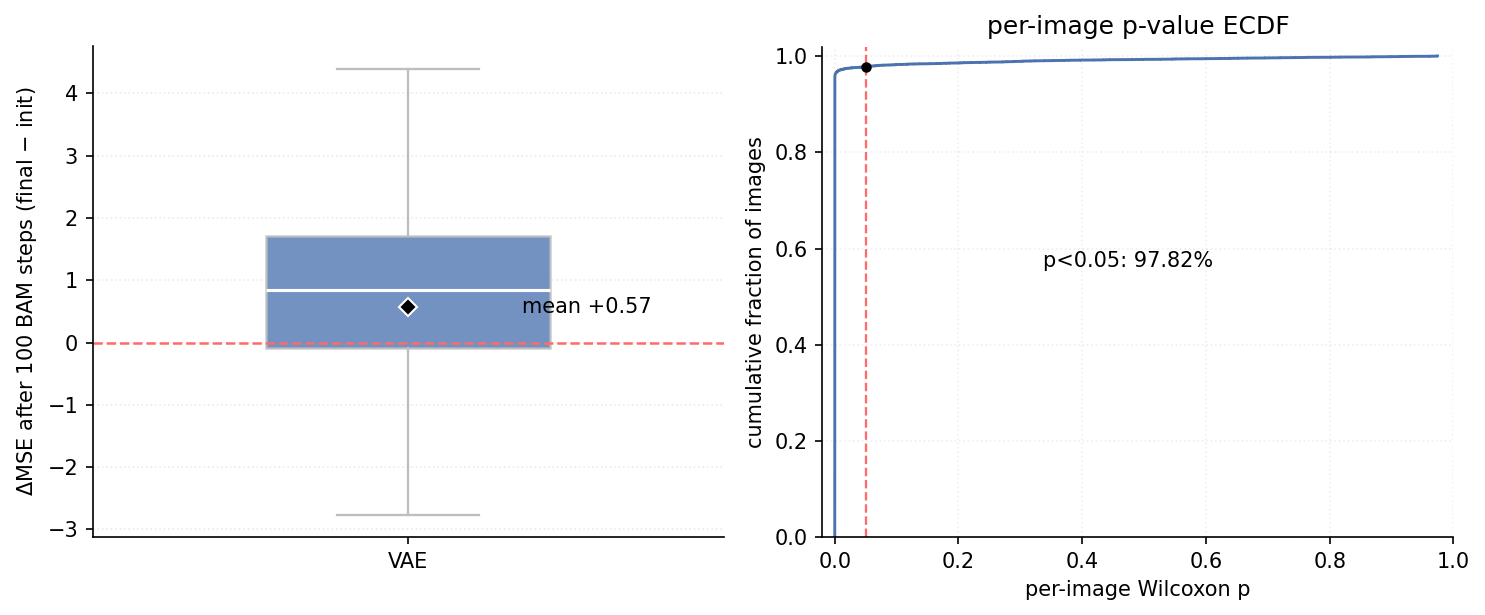

p<0.05 的图像比例: 97.82%


In [ ]:
# ===== 逐图统计 + 最新样式诊断图 =====
# 每张图：其 100 步轨迹相对初始值的差 {MSE_t - MSE_0} 做单样本 Wilcoxon。
# 注意：单图轨迹自相关，此 p 仅作描述统计；全局结论以上一 cell 的跨图配对检验为准。
import matplotlib.pyplot as plt

diffs = curves[:, 1:] - curves[:, [0]]   # [N, T+1]
pvals = np.empty(len(curves))
for i, dd in enumerate(diffs):
    try:
        pvals[i] = sps.wilcoxon(dd).pvalue
    except ValueError:                    # 差值全 0
        pvals[i] = 1.0

method_color = {"vae": "#4C72B0", "sdvae": "#C05A2A"}[METHOD_TAG]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=150)
bp = axes[0].boxplot(
    [delta], showfliers=False, widths=0.45, patch_artist=True,
    boxprops=dict(linewidth=1.2, edgecolor="#BDBDBD"),
    whiskerprops=dict(linewidth=1.1, color="#BDBDBD"),
    capprops=dict(linewidth=1.1, color="#BDBDBD"),
    medianprops=dict(linewidth=1.5, color="white"),
)
bp["boxes"][0].set_facecolor(method_color)
bp["boxes"][0].set_alpha(0.78)
axes[0].axhline(0, color="#FF6B6B", lw=1.2, ls="--")
axes[0].set_xticks([1])
axes[0].set_xticklabels([METHOD_TAG.upper()])
axes[0].set_ylabel(r"$\Delta$MSE after 100 BAM steps (final $-$ init)")
axes[0].yaxis.grid(True, alpha=0.25, ls=":")
axes[0].spines[["top", "right"]].set_visible(False)
mean_delta = delta.mean()
axes[0].plot(1, mean_delta, marker="D", ms=6, color="black",
             markeredgecolor="white", markeredgewidth=1.0, zorder=4)
axes[0].annotate(f"mean {mean_delta:+.2f}", xy=(1.18, mean_delta),
                 va="center", fontsize=10)

frac = (pvals < 0.05).mean()
xs = np.sort(pvals)
ys = np.arange(1, len(xs) + 1) / len(xs)
axes[1].step(xs, ys, where="post", color=method_color, lw=1.4)
axes[1].axvline(0.05, color="#FF6B6B", lw=1.1, ls="--")
axes[1].plot([0.05], [frac], "o", ms=4, color="black")
axes[1].text(0.35, 0.55, f"p<0.05: {frac:.2%}", transform=axes[1].transAxes,
             fontsize=10)
axes[1].set_xlim(-0.02, 1.0)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("per-image Wilcoxon p")
axes[1].set_ylabel("cumulative fraction of images")
axes[1].set_title("per-image p-value ECDF")
axes[1].grid(True, alpha=0.2, ls=":")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/{DATASET}_{METHOD_TAG}_T{T}_diagnostic.png",
            dpi=200, bbox_inches="tight")
plt.show()
print(f"p<0.05 的图像比例: {frac:.2%}")

np.savez_compressed(
    f"{SAVE_DIR}/{DATASET}_{METHOD_TAG}_T{T}_stats.npz",
    indices=indices, mse_init=mse_init, mse_final=mse_final, delta=delta, pvals=pvals,
)


In [17]:
# ===== 可选：整集 FID（t=0 vs t=T）=====
# FID 是集合级指标（一批图像的 Inception 特征分布距离），单张图没有 FID，
# 逐图曲线只能用 MSE；这里用存下的 mu 轨迹算整个 test set 在 t=0 / t=T 的 FID。
import torch.nn.functional as F
from torchmetrics.image.fid import FrechetInceptionDistance
import numpy as np
if not hasattr(np, 'float_'):
    np.float_ = np.float64
    
mu_list = []
for f in files:
    d = np.load(f)
    mu_list.append(d["mu_curves"])
mus = np.concatenate(mu_list)[order]   # [N, T+2, LATENT_DIM]


def fid_at(col, batch=256):
    fid = FrechetInceptionDistance(feature=2048).to(device)  # 全局单实例累积，末尾 compute 一次
    for s0 in range(0, len(indices), batch):
        sel = indices[s0:s0 + batch].astype(np.int64)
        real = test_images[torch.from_numpy(sel)].to(device).view(-1, p, s, s)
        if p == 1:
            real = real.repeat(1, 3, 1, 1)
        with torch.no_grad():
            z = torch.from_numpy(mus[s0:s0 + batch, col]).float().to(device)
            fake = decoder(z).view(-1, p, s, s)
            if p == 1:
                fake = fake.repeat(1, 3, 1, 1)
            real_rs = F.interpolate(real, size=(299, 299), mode="bilinear", align_corners=False)
            fake_rs = F.interpolate(fake, size=(299, 299), mode="bilinear", align_corners=False)
            fid.update((real_rs * 255).to(torch.uint8), real=True)
            fid.update((fake_rs * 255).to(torch.uint8), real=False)
    return fid.compute().item()

print("FID t=0 (amortized):", fid_at(0))
print(f"FID t={T} (refined) :", fid_at(-1))
for t in [1, 2, 5, 10, 20, 50]:
    print(f"FID t={t} :", fid_at(t))


  警告: UserWarning
  消息: Metric `FrechetInceptionDistance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
FID t=0 (amortized): 225.87786865234375
FID t=100 (refined) : 233.464111328125
FID t=1 : 226.69387817382812
FID t=2 : 227.58843994140625


KeyboardInterrupt: 